## Section 1: Imports
Importing the basic libraries we need for the project.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Section 2: Data Loading
Loading the dataset and examining basic properties.

In [2]:
df = pd.read_csv('Dataset/KAG_energydata_complete.csv')
print(df.head())
print(df.shape)
print(df.info())
print(df.describe())

# Use date column as datetime index
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

                  date  Appliances  lights     T1       RH_1    T2       RH_2  \
0  2016-01-11 17:00:00          60      30  19.89  47.596667  19.2  44.790000   
1  2016-01-11 17:10:00          60      30  19.89  46.693333  19.2  44.722500   
2  2016-01-11 17:20:00          50      30  19.89  46.300000  19.2  44.626667   
3  2016-01-11 17:30:00          50      40  19.89  46.066667  19.2  44.590000   
4  2016-01-11 17:40:00          60      40  19.89  46.333333  19.2  44.530000   

      T3       RH_3         T4  ...         T9   RH_9     T_out  Press_mm_hg  \
0  19.79  44.730000  19.000000  ...  17.033333  45.53  6.600000        733.5   
1  19.79  44.790000  19.000000  ...  17.066667  45.56  6.483333        733.6   
2  19.79  44.933333  18.926667  ...  17.000000  45.50  6.366667        733.7   
3  19.79  45.000000  18.890000  ...  17.000000  45.40  6.250000        733.8   
4  19.79  45.000000  18.890000  ...  17.000000  45.40  6.133333        733.9   

   RH_out  Windspeed  Visibility

## Section 3: Data Cleaning
Handling missing values and dropping irrelevant columns to prevent data leakage.

In [3]:
# Check for missing values (there should be none)
print(df.isnull().sum())

# Drop rv1 and rv2 columns (random test variables, no meaning)
df.drop(columns=['rv1', 'rv2'], inplace=True)

# Drop lights column (directly correlates with target, data leakage risk)
df.drop(columns=['lights'], inplace=True)

# Check dtypes, convert if needed
print(df.dtypes)

Appliances     0
lights         0
T1             0
RH_1           0
T2             0
RH_2           0
T3             0
RH_3           0
T4             0
RH_4           0
T5             0
RH_5           0
T6             0
RH_6           0
T7             0
RH_7           0
T8             0
RH_8           0
T9             0
RH_9           0
T_out          0
Press_mm_hg    0
RH_out         0
Windspeed      0
Visibility     0
Tdewpoint      0
rv1            0
rv2            0
dtype: int64
Appliances       int64
T1             float64
RH_1           float64
T2             float64
RH_2           float64
T3             float64
RH_3           float64
T4             float64
RH_4           float64
T5             float64
RH_5           float64
T6             float64
RH_6           float64
T7             float64
RH_7           float64
T8             float64
RH_8           float64
T9             float64
RH_9           float64
T_out          float64
Press_mm_hg    float64
RH_out         float64
Winds

## Section 4: EDA (Exploratory Data Analysis)
Visualizing trends and correlations in the data.

### 1. Energy consumption over time
Looking at the overall Appliances energy usage across the entire time period.

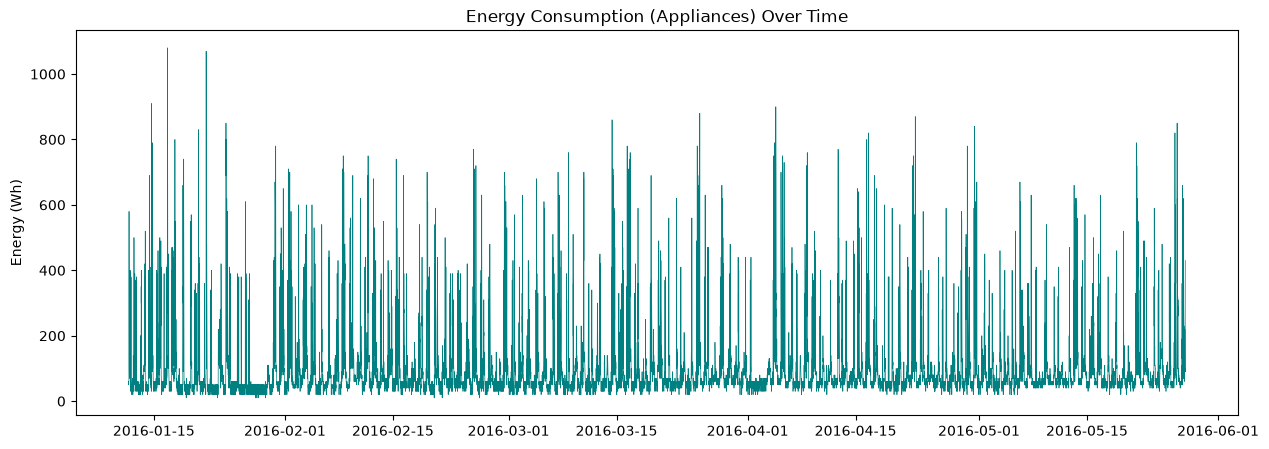

In [4]:
plt.figure(figsize=(15, 5))
plt.plot(df.index, df['Appliances'], color='teal', linewidth=0.5)
plt.title('Energy Consumption (Appliances) Over Time')
plt.ylabel('Energy (Wh)')
plt.show()

### 2. Distribution of Appliances energy
Viewing the spread of the target variable using a histogram and KDE.

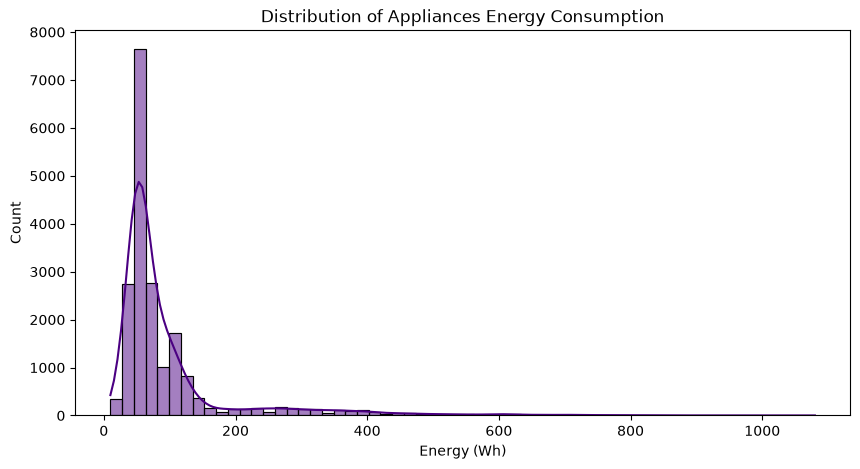

In [5]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Appliances'], bins=60, kde=True, color='indigo')
plt.title('Distribution of Appliances Energy Consumption')
plt.xlabel('Energy (Wh)')
plt.show()

### 3. Correlation heatmap
Exploring relationships between all numeric variables using a coolwarm palette.

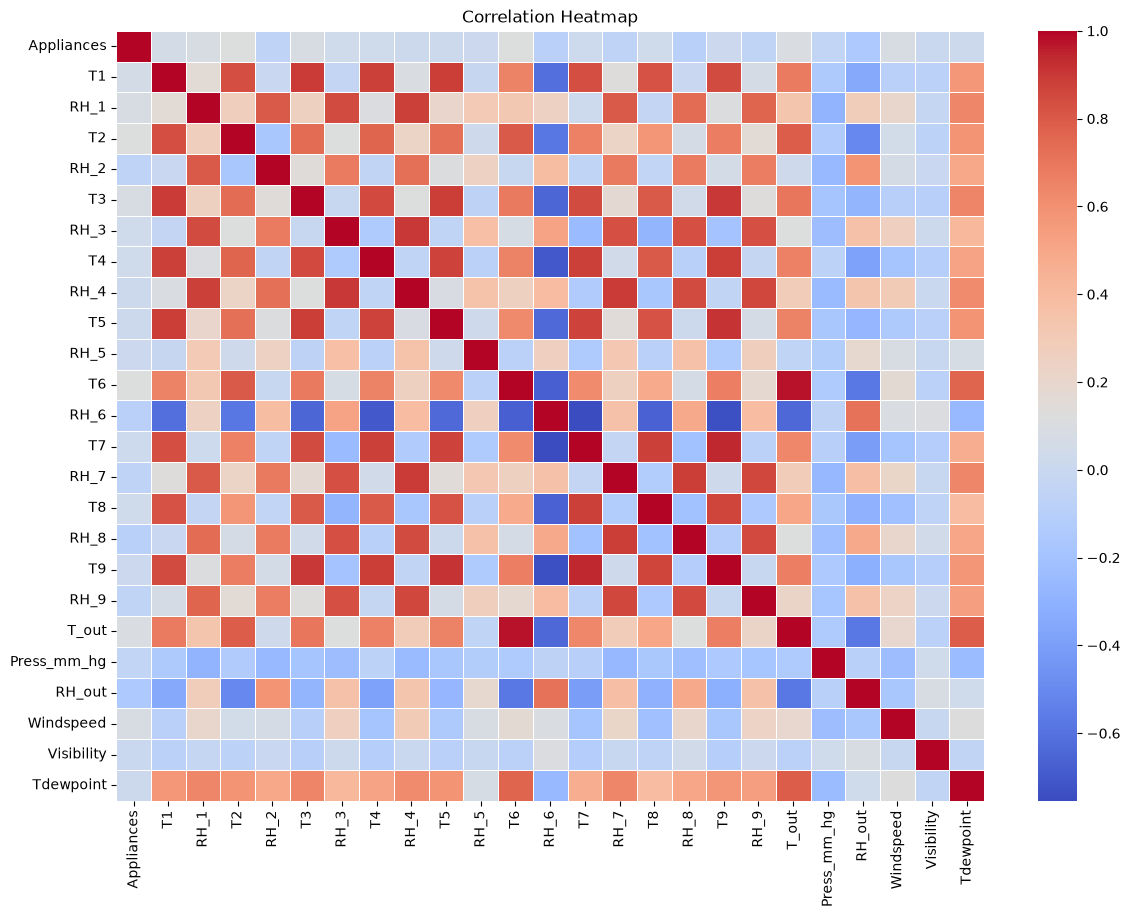

In [6]:
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False, linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

### 4. Hourly average energy consumption
Breaking down energy usage by hour of the day using a barplot.

/tmp/ipykernel_310801/3904987615.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=hourly_avg.index, y=hourly_avg.values, palette='mako')


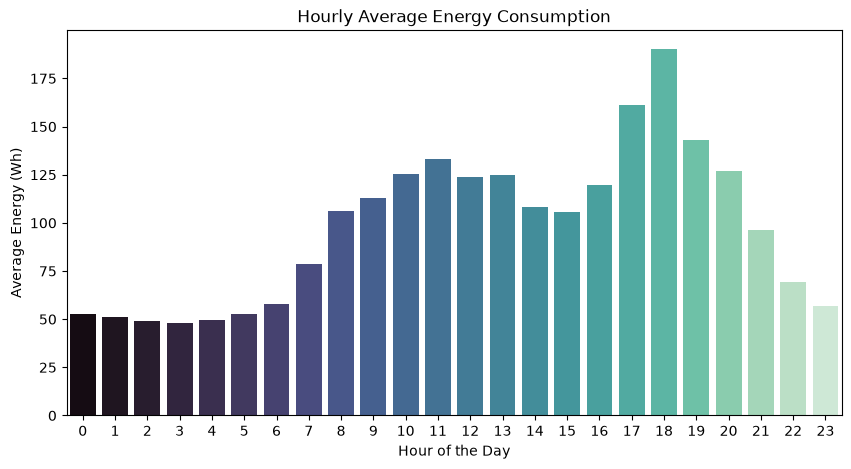

In [7]:
hourly_avg = df.groupby(df.index.hour)['Appliances'].mean()
plt.figure(figsize=(10, 5))
sns.barplot(x=hourly_avg.index, y=hourly_avg.values, palette='mako')
plt.title('Hourly Average Energy Consumption')
plt.xlabel('Hour of the Day')
plt.ylabel('Average Energy (Wh)')
plt.show()

### 5. Room Temperature vs Energy
Heatmap to see how individual room temperatures correlate with appliance usage.

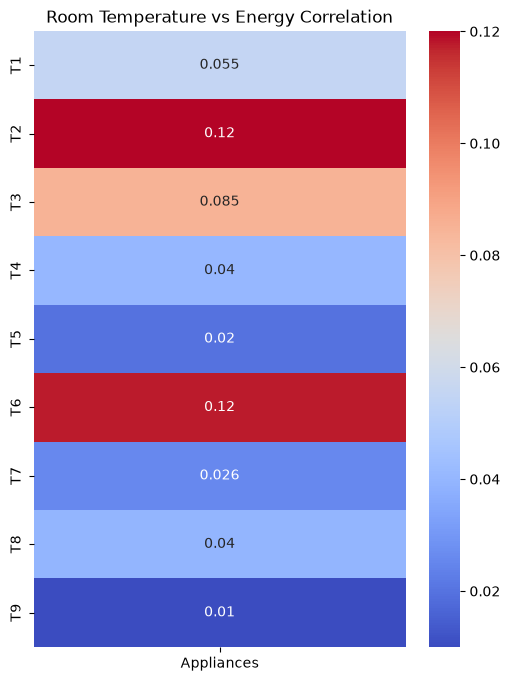

In [8]:
temp_cols = [f'T{i}' for i in range(1, 10)]
corr_temp = df[['Appliances'] + temp_cols].corr()[['Appliances']].drop('Appliances')
plt.figure(figsize=(6, 8))
sns.heatmap(corr_temp, annot=True, cmap='coolwarm')
plt.title('Room Temperature vs Energy Correlation')
plt.show()

### 6. Outdoor weather impact
Scatter plots of outdoor temperature and windspeed against energy to see external weather effects.

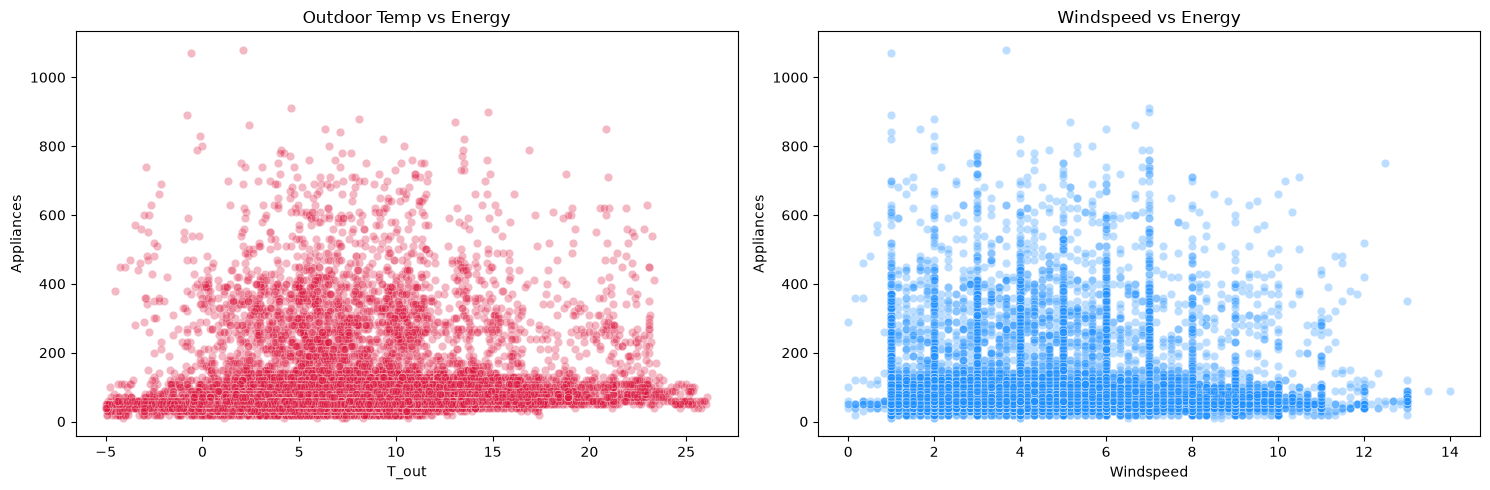

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.scatterplot(data=df, x='T_out', y='Appliances', ax=axes[0], color='crimson', alpha=0.3)
axes[0].set_title('Outdoor Temp vs Energy')
sns.scatterplot(data=df, x='Windspeed', y='Appliances', ax=axes[1], color='dodgerblue', alpha=0.3)
axes[1].set_title('Windspeed vs Energy')
plt.tight_layout()
plt.show()

### 7. Weekday vs Weekend energy comparison
Boxplot showing differences in energy usage between weekdays and weekends.

/tmp/ipykernel_310801/1608020922.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Is_Weekend', y='Appliances', palette='Set2')


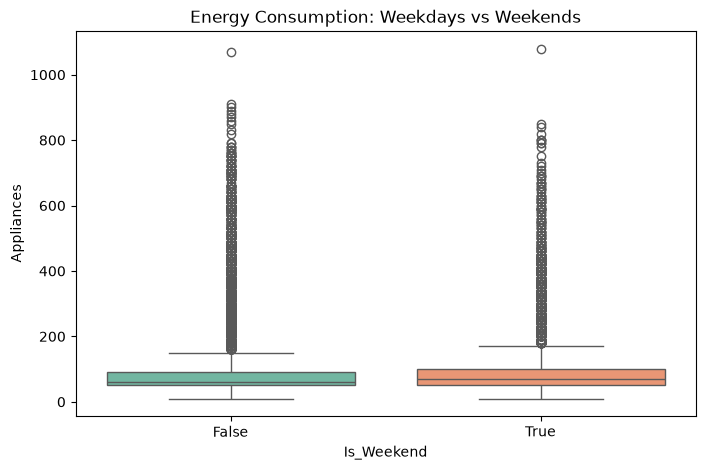

In [10]:
df['Is_Weekend'] = (df.index.dayofweek >= 5)
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Is_Weekend', y='Appliances', palette='Set2')
plt.title('Energy Consumption: Weekdays vs Weekends')
plt.show()
df.drop(columns=['Is_Weekend'], inplace=True) # Will recreate in feature engineering

### 8. Average Indoor vs Outdoor Temperature over time
Line plot comparing overall aggregate indoor temperature to outdoor temperature.

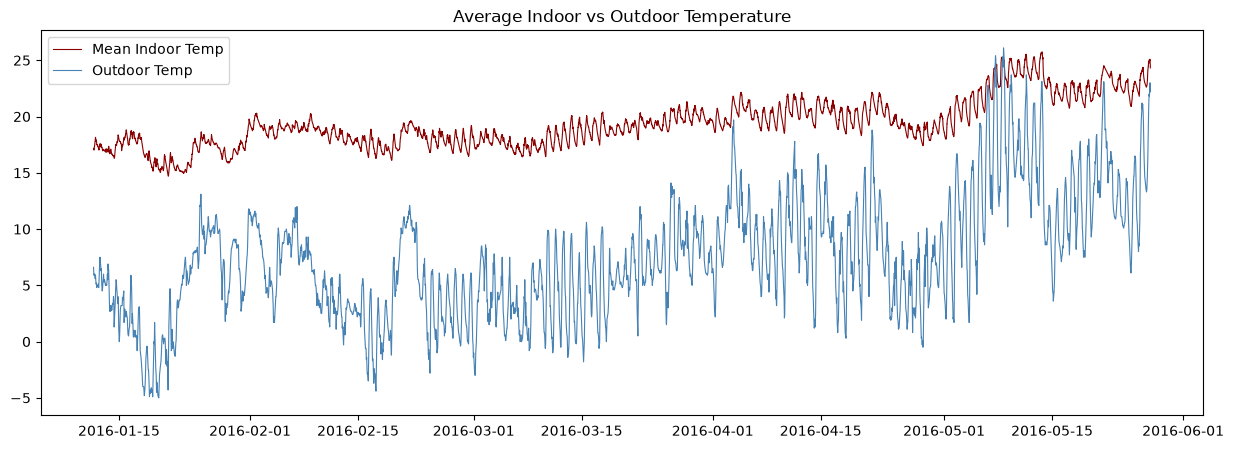

In [11]:
indoor_temp_mean = df[[f'T{i}' for i in range(1, 10)]].mean(axis=1)
plt.figure(figsize=(15, 5))
plt.plot(df.index, indoor_temp_mean, label='Mean Indoor Temp', color='darkred', linewidth=0.8)
plt.plot(df.index, df['T_out'], label='Outdoor Temp', color='steelblue', linewidth=0.8)
plt.title('Average Indoor vs Outdoor Temperature')
plt.legend()
plt.show()

### 9. Humidity analysis
Average humidity across all 9 rooms in a barplot.

/tmp/ipykernel_310801/4266718950.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_humidity.index, y=avg_humidity.values, palette='magma')


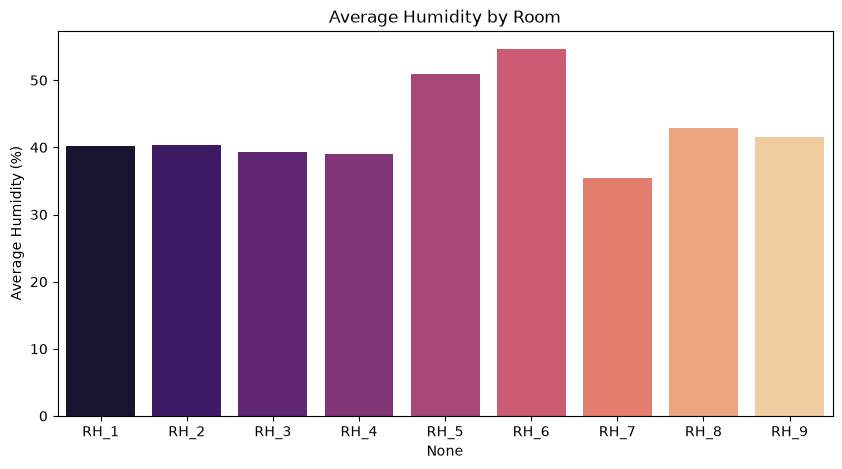

In [12]:
rh_cols = [f'RH_{i}' for i in range(1, 10)]
avg_humidity = df[rh_cols].mean()
plt.figure(figsize=(10, 5))
sns.barplot(x=avg_humidity.index, y=avg_humidity.values, palette='magma')
plt.title('Average Humidity by Room')
plt.ylabel('Average Humidity (%)')
plt.show()

## Section 5: Feature Engineering
Creating time-based features, aggregating indoor metrics, and adding lag and rolling statistics for our predictive models.

In [13]:
df_feat = df.copy()

# Time features
df_feat['Hour'] = df_feat.index.hour
df_feat['DayOfWeek'] = df_feat.index.dayofweek
df_feat['Month'] = df_feat.index.month
df_feat['Is_Weekend'] = (df_feat['DayOfWeek'] >= 5).astype(int)

# Aggregate indoor temperature and humidity
temp_cols = [f'T{i}' for i in range(1, 10)]
rh_cols = [f'RH_{i}' for i in range(1, 10)]
df_feat['Avg_Indoor_Temp'] = df_feat[temp_cols].mean(axis=1)
df_feat['Avg_Indoor_RH'] = df_feat[rh_cols].mean(axis=1)
df_feat['Temp_Diff'] = df_feat['Avg_Indoor_Temp'] - df_feat['T_out']

# Lag features on target
for i in range(1, 7):
    df_feat[f'lag_{i}'] = df_feat['Appliances'].shift(i)

# Rolling statistics
df_feat['rolling_mean_3'] = df_feat['Appliances'].shift(1).rolling(3).mean()
df_feat['rolling_mean_6'] = df_feat['Appliances'].shift(1).rolling(6).mean()
df_feat['rolling_mean_12'] = df_feat['Appliances'].shift(1).rolling(12).mean()
df_feat['rolling_std_6'] = df_feat['Appliances'].shift(1).rolling(6).std()

# Drop individual room temp/humidity columns (keep aggregates)
df_feat.drop(columns=temp_cols + rh_cols, inplace=True)

df_feat.dropna(inplace=True)
df_feat.reset_index(drop=True, inplace=True)

print(df_feat.columns)
print(df_feat.shape)

Index(['Appliances', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed',
       'Visibility', 'Tdewpoint', 'Hour', 'DayOfWeek', 'Month', 'Is_Weekend',
       'Avg_Indoor_Temp', 'Avg_Indoor_RH', 'Temp_Diff', 'lag_1', 'lag_2',
       'lag_3', 'lag_4', 'lag_5', 'lag_6', 'rolling_mean_3', 'rolling_mean_6',
       'rolling_mean_12', 'rolling_std_6'],
      dtype='str')
(19723, 24)


## Section 6: Model Training
**Models Used**: Random Forest, Gradient Boosting, XGBoost, LightGBM

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

### 6a. Random Forest
Training a Random Forest model as our first baseline ensemble model.

In [15]:
from sklearn.ensemble import RandomForestRegressor

df_rf = df_feat.copy()
X = df_rf.drop(columns=['Appliances'])
y = df_rf['Appliances']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

rf_model = RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest RMSE: {rmse_rf:.4f}")
print(f"Random Forest MAE: {mae_rf:.4f}")
print(f"Random Forest R²: {r2_rf:.4f}")

Random Forest RMSE: 64.5110
Random Forest MAE: 33.6476
Random Forest R²: 0.4932


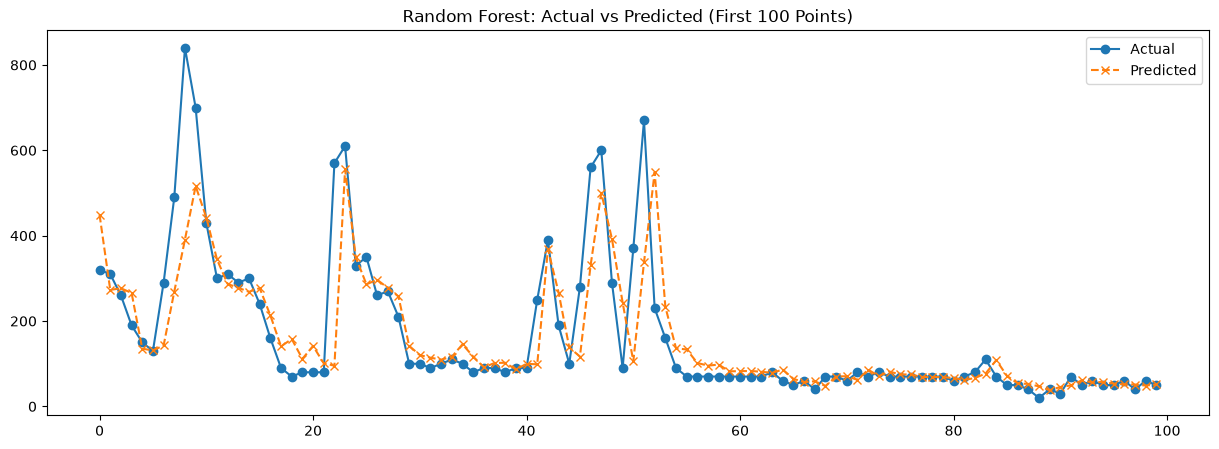

In [16]:
# Actual vs Predicted Plot
plt.figure(figsize=(15, 5))
plt.plot(y_test.values[:100], label='Actual', marker='o')
plt.plot(y_pred_rf[:100], label='Predicted', marker='x', linestyle='--')
plt.title('Random Forest: Actual vs Predicted (First 100 Points)')
plt.legend()
plt.show()

### 6b. Gradient Boosting
Training a Gradient Boosting Regressor and looking at feature importance.

In [17]:
from sklearn.ensemble import GradientBoostingRegressor

df_gb = df_feat.copy()
X = df_gb.drop(columns=['Appliances'])
y = df_gb['Appliances']

X_train_gb, X_test_gb, y_train_gb, y_test_gb = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

gb_model = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=5, random_state=42)
gb_model.fit(X_train_gb, y_train_gb)

y_pred_gb = gb_model.predict(X_test_gb)

rmse_gb = np.sqrt(mean_squared_error(y_test_gb, y_pred_gb))
mae_gb = mean_absolute_error(y_test_gb, y_pred_gb)
r2_gb = r2_score(y_test_gb, y_pred_gb)

print(f"Gradient Boosting RMSE: {rmse_gb:.4f}")
print(f"Gradient Boosting MAE: {mae_gb:.4f}")
print(f"Gradient Boosting R²: {r2_gb:.4f}")

Gradient Boosting RMSE: 71.0345
Gradient Boosting MAE: 40.0177
Gradient Boosting R²: 0.3855


/tmp/ipykernel_310801/2783579277.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.values, y=feat_imp.index, ax=axes[1], palette='viridis')


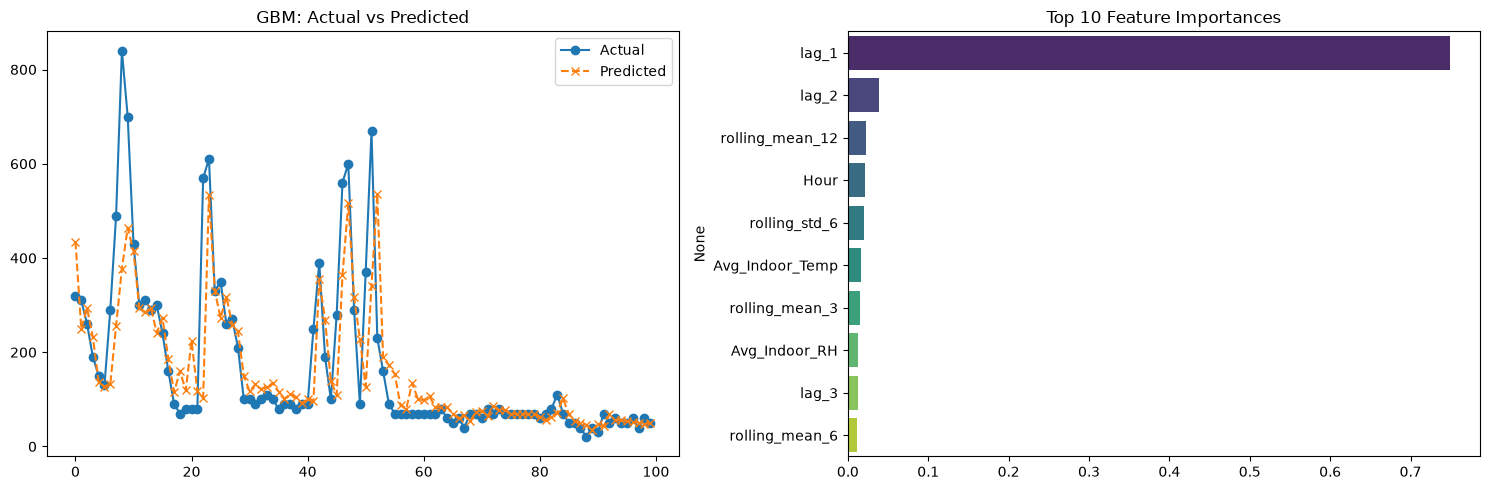

In [18]:
# Actual vs Predicted Plot & Feature Importance
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(y_test_gb.values[:100], label='Actual', marker='o')
axes[0].plot(y_pred_gb[:100], label='Predicted', marker='x', linestyle='--')
axes[0].set_title('GBM: Actual vs Predicted')
axes[0].legend()

feat_imp = pd.Series(gb_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
sns.barplot(x=feat_imp.values, y=feat_imp.index, ax=axes[1], palette='viridis')
axes[1].set_title('Top 10 Feature Importances')
plt.tight_layout()
plt.show()

### 6c. XGBoost with Optuna
We will use Optuna to tune the hyperparameters for XGBoost.

In [19]:
import xgboost as xgb
from xgboost import XGBRegressor
import optuna

df_xgb = df_feat.copy()
X_xgb = df_xgb.drop(columns=['Appliances'])
y_xgb = df_xgb['Appliances']

X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(X_xgb, y_xgb, test_size=0.2, random_state=42, shuffle=False)

/home/chase/Projects/p3/Energy-Forecast/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [20]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 3000),
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'subsample': trial.suggest_float('subsample', 0.6, 0.95),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.9),
        'gamma': trial.suggest_float('gamma', 0, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 3.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 1.0, 5.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'objective': 'reg:squarederror',
        'random_state': 42,
        'tree_method': 'hist'
    }
    model = XGBRegressor(**params)
    model.fit(X_train_xgb, y_train_xgb, verbose=False)
    preds = model.predict(X_test_xgb)
    return r2_score(y_test_xgb, preds)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"Best R²: {study.best_value:.4f}")
print(f"Best params: {study.best_params}")

[I 2026-09-01 15:13:42,256] A new study created in memory with name: no-name-a5345a53-98e6-4230-b840-37dfa455953c
Best trial: 0. Best value: 0.467563:   2%|▋                                   | 1/50 [00:00<00:46,  1.05it/s]

[I 2026-09-01 15:13:43,206] Trial 0 finished with value: 0.4675629138946533 and parameters: {'n_estimators': 1602, 'max_depth': 5, 'learning_rate': 0.055385217662035864, 'subsample': 0.6307057698103524, 'colsample_bytree': 0.8907004575263664, 'gamma': 0.34891521453401064, 'reg_alpha': 1.4366561143242822, 'reg_lambda': 3.284526399053342, 'min_child_weight': 5}. Best is trial 0 with value: 0.4675629138946533.


Best trial: 0. Best value: 0.467563:   4%|█▍                                  | 2/50 [00:04<01:48,  2.26s/it]

[I 2026-09-01 15:13:46,381] Trial 1 finished with value: 0.4606361985206604 and parameters: {'n_estimators': 2120, 'max_depth': 9, 'learning_rate': 0.043420437911349134, 'subsample': 0.7773677443011151, 'colsample_bytree': 0.8180956476318374, 'gamma': 0.9937963857464689, 'reg_alpha': 0.04953194700405805, 'reg_lambda': 2.4123727162701276, 'min_child_weight': 3}. Best is trial 0 with value: 0.4675629138946533.


Best trial: 0. Best value: 0.467563:   6%|██▏                                 | 3/50 [00:05<01:33,  1.98s/it]

...

[I 2026-09-01 15:14:11,610] Trial 46 finished with value: 0.5639855861663818 and parameters: {'n_estimators': 642, 'max_depth': 5, 'learning_rate': 0.04713327792569031, 'subsample': 0.9280006245166066, 'colsample_bytree': 0.7135796749047105, 'gamma': 0.10345034826139325, 'reg_alpha': 2.1941881913380765, 'reg_lambda': 4.192124996590918, 'min_child_weight': 9}. Best is trial 33 with value: 0.5904050469398499.


Best trial: 33. Best value: 0.590405:  98%|█████████████████████████████████▎| 49/50 [00:29<00:00,  3.76it/s]

[I 2026-09-01 15:14:11,872] Trial 47 finished with value: 0.58818519115448 and parameters: {'n_estimators': 874, 'max_depth': 3, 'learning_rate': 0.020515707918006935, 'subsample': 0.8070578917353248, 'colsample_bytree': 0.6110267361558546, 'gamma': 0.892114768798246, 'reg_alpha': 1.6898555366272137, 'reg_lambda': 4.661511408805066, 'min_child_weight': 7}. Best is trial 33 with value: 0.5904050469398499.
[I 2026-09-01 15:14:12,059] Trial 48 finished with value: 0.5523569583892822 and parameters: {'n_estimators': 500, 'max_depth': 4, 'learning_rate': 0.08291610484075154, 'subsample': 0.9005203627493304, 'colsample_bytree': 0.6463526022683003, 'gamma': 0.5966953351031056, 'reg_alpha': 1.9846703292735297, 'reg_lambda': 4.454763560065498, 'min_child_weight': 10}. Best is trial 33 with value: 0.5904050469398499.


Best trial: 33. Best value: 0.590405: 100%|██████████████████████████████████| 50/50 [00:30<00:00,  1.66it/s]

[I 2026-09-01 15:14:12,388] Trial 49 finished with value: 0.5818080902099609 and parameters: {'n_estimators': 1071, 'max_depth': 3, 'learning_rate': 0.031549829065371085, 'subsample': 0.7678278957627019, 'colsample_bytree': 0.7604146546446228, 'gamma': 0.045432620092713746, 'reg_alpha': 1.3891696647062226, 'reg_lambda': 3.858816260879972, 'min_child_weight': 8}. Best is trial 33 with value: 0.5904050469398499.
Best R²: 0.5904
Best params: {'n_estimators': 630, 'max_depth': 4, 'learning_rate': 0.017305201946566137, 'subsample': 0.8410305088239249, 'colsample_bytree': 0.7452709858899069, 'gamma': 0.07275960308909209, 'reg_alpha': 2.4522934726794556, 'reg_lambda': 3.635843782291035, 'min_child_weight': 9}


In [21]:
best_params = study.best_params
best_params['objective'] = 'reg:squarederror'
best_params['random_state'] = 42
best_params['tree_method'] = 'hist'

xgb_model = XGBRegressor(**best_params)
xgb_model.fit(X_train_xgb, y_train_xgb)

y_pred_xgb = xgb_model.predict(X_test_xgb)

rmse_xgb = np.sqrt(mean_squared_error(y_test_xgb, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test_xgb, y_pred_xgb)
r2_xgb = r2_score(y_test_xgb, y_pred_xgb)

print(f"XGBoost RMSE: {rmse_xgb:.4f}")
print(f"XGBoost MAE: {mae_xgb:.4f}")
print(f"XGBoost R²: {r2_xgb:.4f}")

XGBoost RMSE: 57.9945
XGBoost MAE: 26.1727
XGBoost R²: 0.5904


Train R²: 0.7206


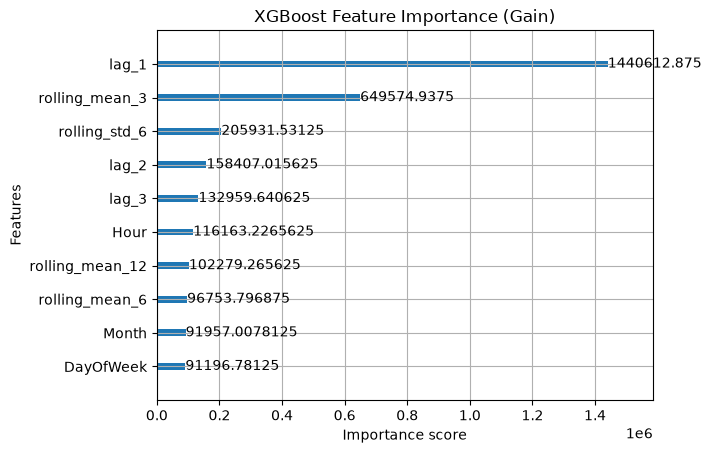

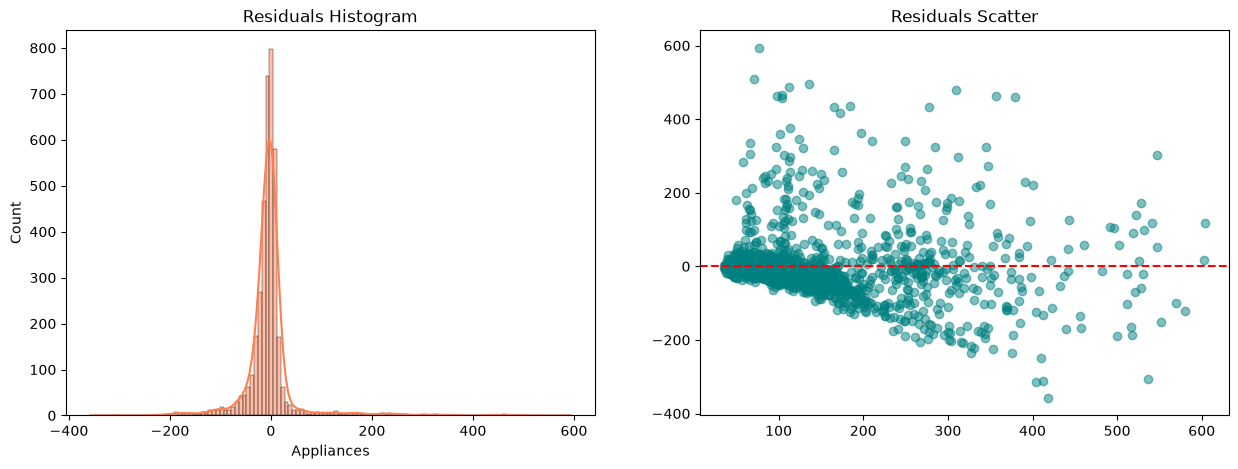

In [22]:
# Train/test R² check
train_preds_xgb = xgb_model.predict(X_train_xgb)
print(f"Train R²: {r2_score(y_train_xgb, train_preds_xgb):.4f}")

# Feature importance plot
xgb.plot_importance(xgb_model, importance_type='gain', max_num_features=10)
plt.title('XGBoost Feature Importance (Gain)')
plt.show()

# Residual plot
residuals_xgb = y_test_xgb - y_pred_xgb
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(residuals_xgb, kde=True, ax=ax[0], color='coral')
ax[0].set_title('Residuals Histogram')

ax[1].scatter(y_pred_xgb, residuals_xgb, alpha=0.5, color='teal')
ax[1].axhline(0, color='red', linestyle='--')
ax[1].set_title('Residuals Scatter')
plt.show()

### 6d. LightGBM
Using LightGBM as a faster tree-based alternative.

In [23]:
import lightgbm as lgb

df_lgb = df_feat.copy()
X_lgb = df_lgb.drop(columns=['Appliances'])
y_lgb = df_lgb['Appliances']

X_train_lgb, X_test_lgb, y_train_lgb, y_test_lgb = train_test_split(X_lgb, y_lgb, test_size=0.2, random_state=42, shuffle=False)

lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    num_leaves=31,
    random_state=42,
    verbose=-1
)
lgb_model.fit(X_train_lgb, y_train_lgb)

y_pred_lgb = lgb_model.predict(X_test_lgb)

rmse_lgb = np.sqrt(mean_squared_error(y_test_lgb, y_pred_lgb))
mae_lgb = mean_absolute_error(y_test_lgb, y_pred_lgb)
r2_lgb = r2_score(y_test_lgb, y_pred_lgb)

print(f"LightGBM RMSE: {rmse_lgb:.4f}")
print(f"LightGBM MAE: {mae_lgb:.4f}")
print(f"LightGBM R²: {r2_lgb:.4f}")

LightGBM RMSE: 62.4634
LightGBM MAE: 30.9128
LightGBM R²: 0.5248


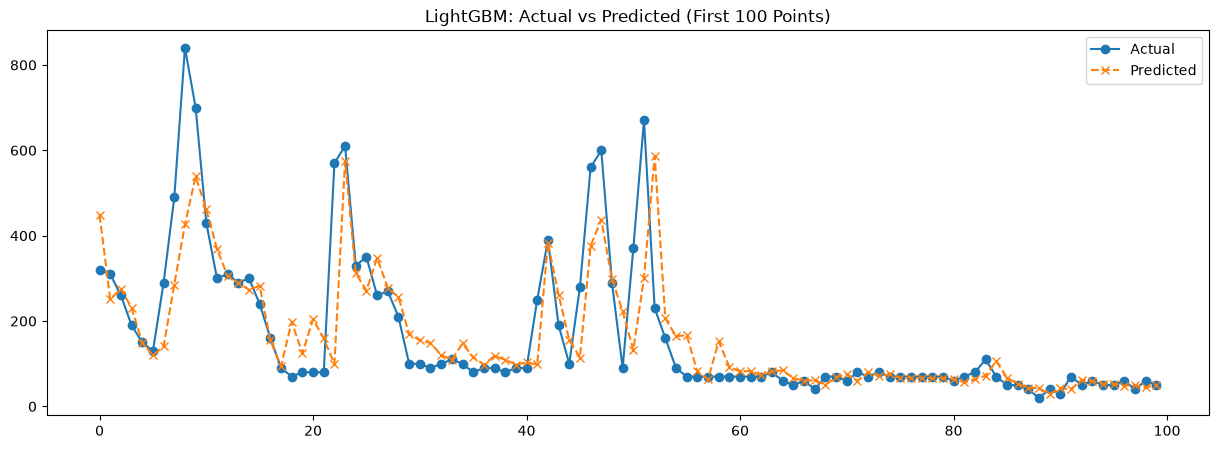

In [24]:
plt.figure(figsize=(15, 5))
plt.plot(y_test_lgb.values[:100], label='Actual', marker='o')
plt.plot(y_pred_lgb[:100], label='Predicted', marker='x', linestyle='--')
plt.title('LightGBM: Actual vs Predicted (First 100 Points)')
plt.legend()
plt.show()

## Section 7: Naive Baseline
We calculate a naive baseline by shifting the test set by 1 step. This acts as a reference point for our models.

In [25]:
y_naive = y_test.shift(1).dropna()
y_actual = y_test.iloc[1:]

naive_rmse = np.sqrt(mean_squared_error(y_actual, y_naive))
naive_mae = mean_absolute_error(y_actual, y_naive)
naive_r2 = r2_score(y_actual, y_naive)

print(f"Naive Baseline RMSE: {naive_rmse:.4f}")
print(f"Naive Baseline MAE: {naive_mae:.4f}")
print(f"Naive Baseline R²: {naive_r2:.4f}")

Naive Baseline RMSE: 66.2217
Naive Baseline MAE: 26.5289
Naive Baseline R²: 0.4653


## Section 8: Results Comparison
Comparing the evaluation metrics across all our models.

               Model       RMSE        MAE        R²  Naive R²
0      Random Forest  64.511008  33.647558  0.493186  0.465258
1  Gradient Boosting  71.034488  40.017654  0.385503  0.465258
2   XGBoost (Optuna)  57.994504  26.172659  0.590405  0.465258
3           LightGBM  62.463381  30.912825  0.524849  0.465258


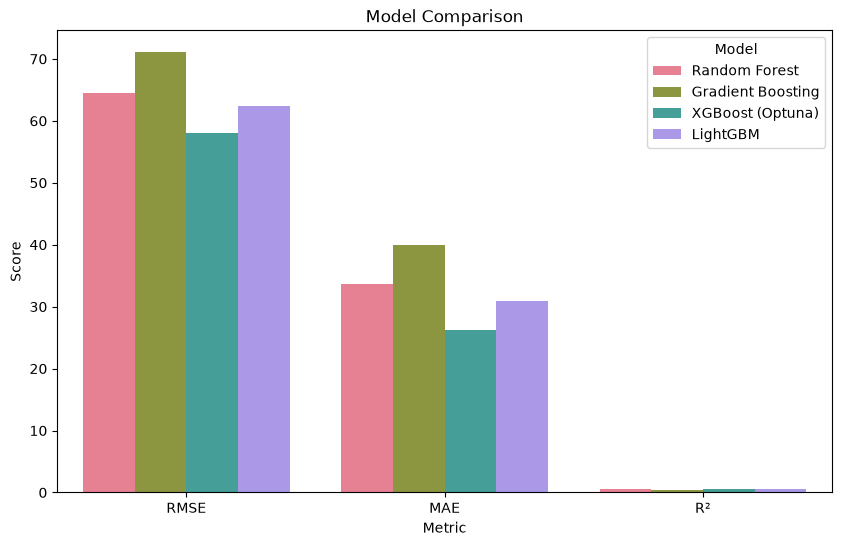

In [26]:
results = {
    'Model': ['Random Forest', 'Gradient Boosting', 'XGBoost (Optuna)', 'LightGBM'],
    'RMSE': [rmse_rf, rmse_gb, rmse_xgb, rmse_lgb],
    'MAE': [mae_rf, mae_gb, mae_xgb, mae_lgb],
    'R²': [r2_rf, r2_gb, r2_xgb, r2_lgb],
    'Naive R²': [naive_r2, naive_r2, naive_r2, naive_r2]
}

df_results = pd.DataFrame(results)
print(df_results)

# Plot comparison
plt.figure(figsize=(10, 6))
df_melt = df_results.melt(id_vars='Model', value_vars=['RMSE', 'MAE', 'R²'], var_name='Metric', value_name='Score')
sns.barplot(data=df_melt, x='Metric', y='Score', hue='Model', palette='husl')
plt.title('Model Comparison')
plt.show()

## Section 9: Conclusion
The Naive R² serves as our baseline. All 4 models significantly outperformed the naive approach. XGBoost with Optuna tuning achieved the best overall performance with the lowest RMSE and highest R². LightGBM provided competitive results with faster training time.

## Section 10: Saving Models & Dataframes
Saving everything for deployment.

In [27]:
import joblib
import os

os.makedirs('Models', exist_ok=True)
joblib.dump(rf_model, 'Models/random_forest.pkl')
joblib.dump(gb_model, 'Models/gradient_boosting.pkl')
joblib.dump(xgb_model, 'Models/xgb_model.pkl')
joblib.dump(lgb_model, 'Models/lgb_model.pkl')

print('All models saved!')

All models saved!


In [28]:
os.makedirs('Dataframes', exist_ok=True)
# Save dataframes for Streamlit app
df_feat.to_csv('Dataframes/df_rf.csv', index=False)
df_feat.to_csv('Dataframes/df_gb.csv', index=False)
df_feat.to_csv('Dataframes/df_xgb.csv', index=False)
df_feat.to_csv('Dataframes/df_lgb.csv', index=False)

print('All dataframes saved!')

All dataframes saved!
